# 05 — Retrieval Benchmark: MedCPT vs BioLORD

Compare retrieval performance using **MedCPT** (contrastive-trained for medical retrieval) against the BioLORD baseline from notebook 04.

**Experiments:**
1. **MedCPT symmetric (flat)** — Article encoder for both train and test, truncated to 512 tokens
2. **MedCPT symmetric (chunked mean_max)** — Article encoder with chunking + mean_max aggregation
3. **MedCPT asymmetric (flat)** — Query encoder for test (64 tokens), Article encoder for train (512 tokens)

**Baseline (from notebook 04):**
- BioLORD flat: Hit@10 = 0.3774, MRR = 0.1937
- BioLORD chunked mean_max: Hit@10 = 0.4304, MRR = 0.2270

#### Imports

In [1]:
# # Colab only: install and import
# !git clone https://github.com/amlopeza/rare_disease_diagnosis.git
# %cd rare_disease_diagnosis

In [2]:
import numpy as np
import pandas as pd
import pickle
from collections import Counter

from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sys
sys.path.append('../')

from src.chunking import chunk_text, chunk_texts, aggregate_chunk_embeddings

### Configuration

In [4]:
CHUNK_SIZE = 150
OVERLAP = 20
MAX_CHUNKS = 15
AGGREGATION = "mean_max"  # best strategy from notebook 03

### Load retrieval split

In [5]:
# # Colab only
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# # # Colab only
# with open("/content/drive/MyDrive/Colab Notebooks/Projects/rare_disease_diagnosis/dataset/split_retrieval.pkl", "rb") as f:
#     X_train_ret, X_test_ret, y_train_ret, y_test_ret = pickle.load(f)

# Local
with open("../data/split_retrieval.pkl", "rb") as f:
    X_train_ret, X_test_ret, y_train_ret, y_test_ret = pickle.load(f)

print(f"Train: {len(X_train_ret)}  |  Test: {len(X_test_ret)}")
print(f"Train classes: {y_train_ret.nunique()}  |  Test classes: {y_test_ret.nunique()}")

Train: 5532  |  Test: 1383
Train classes: 942  |  Test classes: 530


### Chunk texts (for chunked experiments)

In [7]:
train_chunks, train_doc_lengths = chunk_texts(
    X_train_ret, chunk_size=CHUNK_SIZE, overlap=OVERLAP, max_chunks=MAX_CHUNKS
)
test_chunks, test_doc_lengths = chunk_texts(
    X_test_ret, chunk_size=CHUNK_SIZE, overlap=OVERLAP, max_chunks=MAX_CHUNKS
)

print(f"Train: {len(X_train_ret)} docs → {len(train_chunks)} chunks "
      f"(avg {len(train_chunks)/len(X_train_ret):.1f} chunks/doc)")
print(f"Test:  {len(X_test_ret)} docs → {len(test_chunks)} chunks "
      f"(avg {len(test_chunks)/len(X_test_ret):.1f} chunks/doc)")

Train: 5532 docs → 16536 chunks (avg 3.0 chunks/doc)
Test:  1383 docs → 4260 chunks (avg 3.1 chunks/doc)


---
## Generate embeddings (Colab only — GPU)

Run this section on Colab. It generates all MedCPT embedding variants and saves them to Drive.

#### Experiment 1: MedCPT symmetric flat (article encoder for both sides)

In [6]:
# # Colab only: MedCPT symmetric flat — article encoder for both train and test
# from src.embeddings import load_medcpt, generate_embeddings_medcpt

# tokenizer_art, model_art, max_len_art = load_medcpt(encoder_type="article")

# train_emb_sym_flat = generate_embeddings_medcpt(
#     X_train_ret, tokenizer_art, model_art, max_len_art, batch_size=64
# )
# test_emb_sym_flat = generate_embeddings_medcpt(
#     X_test_ret, tokenizer_art, model_art, max_len_art, batch_size=64
# )

# print(f"Train: {train_emb_sym_flat.shape}  |  Test: {test_emb_sym_flat.shape}")

#### Experiment 2: MedCPT symmetric chunked mean_max (article encoder)

In [7]:
# # Colab only: MedCPT symmetric chunked — article encoder + chunking + mean_max
# train_chunk_emb_art = generate_embeddings_medcpt(
#     train_chunks, tokenizer_art, model_art, max_len_art, batch_size=64
# )
# test_chunk_emb_art = generate_embeddings_medcpt(
#     test_chunks, tokenizer_art, model_art, max_len_art, batch_size=64
# )

# from src.chunking import aggregate_chunk_embeddings

# train_emb_sym_chunked = aggregate_chunk_embeddings(train_chunk_emb_art, train_doc_lengths, method="mean_max")
# test_emb_sym_chunked = aggregate_chunk_embeddings(test_chunk_emb_art, test_doc_lengths, method="mean_max")

# print(f"Train: {train_emb_sym_chunked.shape}  |  Test: {test_emb_sym_chunked.shape}")

#### Experiment 3: MedCPT asymmetric flat (query encoder for test, article encoder for train)

This is the **intended use** of MedCPT: query encoder encodes the "question" (test case) and article encoder encodes the "documents" (train cases). Note: query encoder has a 64-token limit, so heavy truncation is expected.

In [8]:
# # Colab only: MedCPT asymmetric flat — query encoder for test, article encoder for train
# tokenizer_qry, model_qry, max_len_qry = load_medcpt(encoder_type="query")

# # Train uses article encoder (already computed above)
# train_emb_asym_flat = train_emb_sym_flat  # reuse article embeddings

# # Test uses query encoder (64 tokens — heavy truncation)
# test_emb_asym_flat = generate_embeddings_medcpt(
#     X_test_ret, tokenizer_qry, model_qry, max_len_qry, batch_size=64
# )

# print(f"Train: {train_emb_asym_flat.shape}  |  Test: {test_emb_asym_flat.shape}")

#### Save all embeddings

In [9]:
# # Colab only: save all MedCPT embedding variants
# import os

# BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Projects/rare_disease_diagnosis/dataset/"
# output_path = os.path.join(BASE_PATH, "embeddings_medcpt_retrieval.pkl")

# with open(output_path, "wb") as f:
#     pickle.dump({
#         # Experiment 1: symmetric flat
#         "train_emb_sym_flat": train_emb_sym_flat,
#         "test_emb_sym_flat": test_emb_sym_flat,
#         # Experiment 2: symmetric chunked mean_max
#         "train_emb_sym_chunked": train_emb_sym_chunked,
#         "test_emb_sym_chunked": test_emb_sym_chunked,
#         # Experiment 3: asymmetric flat
#         "train_emb_asym_flat": train_emb_asym_flat,
#         "test_emb_asym_flat": test_emb_asym_flat,
#         # Labels
#         "y_train": y_train_ret,
#         "y_test": y_test_ret,
#         # Config
#         "config": {
#             "chunk_size": CHUNK_SIZE,
#             "overlap": OVERLAP,
#             "max_chunks": MAX_CHUNKS,
#             "aggregation": AGGREGATION,
#             "model_article": "ncbi/MedCPT-Article-Encoder",
#             "model_query": "ncbi/MedCPT-Query-Encoder",
#         }
#     }, f)

# print(f"Saved: {output_path}")

---
## Retrieval evaluation (local)

Load pre-computed MedCPT embeddings and evaluate retrieval performance.

In [10]:
path = "../data/embeddings_medcpt_retrieval.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

# Unpack all experiments
train_emb_sym_flat = data["train_emb_sym_flat"]
test_emb_sym_flat = data["test_emb_sym_flat"]
train_emb_sym_chunked = data["train_emb_sym_chunked"]
test_emb_sym_chunked = data["test_emb_sym_chunked"]
train_emb_asym_flat = data["train_emb_asym_flat"]
test_emb_asym_flat = data["test_emb_asym_flat"]
y_train = data["y_train"]
y_test = data["y_test"]
config = data["config"]

print(f"Config: {config}")
print(f"\nShapes:")
print(f"  Sym flat    — Train: {train_emb_sym_flat.shape}  Test: {test_emb_sym_flat.shape}")
print(f"  Sym chunked — Train: {train_emb_sym_chunked.shape}  Test: {test_emb_sym_chunked.shape}")
print(f"  Asym flat   — Train: {train_emb_asym_flat.shape}  Test: {test_emb_asym_flat.shape}")

Config: {'chunk_size': 150, 'overlap': 20, 'max_chunks': 15, 'aggregation': 'mean_max', 'model_article': 'ncbi/MedCPT-Article-Encoder', 'model_query': 'ncbi/MedCPT-Query-Encoder'}

Shapes:
  Sym flat    — Train: (5532, 768)  Test: (1383, 768)
  Sym chunked — Train: (5532, 1536)  Test: (1383, 1536)
  Asym flat   — Train: (5532, 768)  Test: (1383, 768)


#### Filter test set: remove queries with no train representative

In [11]:
train_classes = set(y_train)
test_mask = y_test.isin(train_classes).values

n_excluded = (~test_mask).sum()
print(f"Test samples excluded (class not in train): {n_excluded}")
print(f"Evaluable test samples: {test_mask.sum()} / {len(y_test)}")

y_test_eval = y_test[test_mask].reset_index(drop=True)
print(f"Evaluable test classes: {y_test_eval.nunique()}")

Test samples excluded (class not in train): 82
Evaluable test samples: 1301 / 1383
Evaluable test classes: 460


### Retrieval metrics

In [12]:
K_MAX = 20
KS = [1, 3, 5, 10, 20]

def hit_at_k(y_true, retrieved_labels, k):
    """Fraction of queries where the correct label appears in top-k."""
    return np.mean([y_true[i] in retrieved_labels[i, :k]
                    for i in range(len(y_true))])

def mrr(y_true, retrieved_labels):
    """Mean Reciprocal Rank: average of 1/rank of first correct hit."""
    rr = []
    for i in range(len(y_true)):
        positions = np.where(retrieved_labels[i] == y_true[i])[0]
        if len(positions) > 0:
            rr.append(1.0 / (positions[0] + 1))
        else:
            rr.append(0.0)
    return np.mean(rr)

def evaluate_retrieval(train_emb, test_emb, y_train, y_test_eval, test_mask, k_max=K_MAX):
    """Run k-NN retrieval and return hits dict + MRR."""
    nn = NearestNeighbors(n_neighbors=k_max, metric="cosine")
    nn.fit(train_emb)

    distances, indices = nn.kneighbors(test_emb[test_mask])
    y_train_arr = y_train.values
    retrieved_labels = y_train_arr[indices]
    y_true = y_test_eval.values

    hits = {k: hit_at_k(y_true, retrieved_labels, k) for k in KS}
    mrr_score = mrr(y_true, retrieved_labels)

    return hits, mrr_score, distances, retrieved_labels

### Run all experiments

In [13]:
experiments = {
    "MedCPT sym flat": (train_emb_sym_flat, test_emb_sym_flat),
    "MedCPT sym chunked": (train_emb_sym_chunked, test_emb_sym_chunked),
    "MedCPT asym flat": (train_emb_asym_flat, test_emb_asym_flat),
}

results = {}
for name, (tr_emb, te_emb) in experiments.items():
    print(f"Evaluating: {name} ...")
    hits, mrr_score, dists, ret_labels = evaluate_retrieval(
        tr_emb, te_emb, y_train, y_test_eval, test_mask
    )
    results[name] = {"hits": hits, "mrr": mrr_score, "distances": dists, "retrieved_labels": ret_labels}

    print(f"  Hit@1={hits[1]:.4f}  Hit@5={hits[5]:.4f}  Hit@10={hits[10]:.4f}  MRR={mrr_score:.4f}")
    print()

Evaluating: MedCPT sym flat ...
  Hit@1=0.1668  Hit@5=0.3559  Hit@10=0.4481  MRR=0.2536

Evaluating: MedCPT sym chunked ...
  Hit@1=0.1814  Hit@5=0.3743  Hit@10=0.4704  MRR=0.2691

Evaluating: MedCPT asym flat ...
  Hit@1=0.0799  Hit@5=0.1975  Hit@10=0.2690  MRR=0.1381



### Comparison table: MedCPT vs BioLORD

In [14]:
# BioLORD baselines from notebook 04
biolord_results = {
    "BioLORD flat": {
        "hits": {1: 0.1184, 3: 0.2229, 5: 0.2767, 10: 0.3774, 20: 0.4766},
        "mrr": 0.1937,
    },
    "BioLORD chunked mean_max": {
        "hits": {1: 0.1414, 3: 0.2606, 5: 0.3251, 10: 0.4304, 20: 0.5204},
        "mrr": 0.2270,
    },
}

# Build comparison dataframe
rows = []
all_results = {**biolord_results, **{k: v for k, v in results.items()}}

for name, res in all_results.items():
    row = {"Model": name}
    for k in KS:
        row[f"Hit@{k}"] = res["hits"][k]
    row["MRR"] = res["mrr"]
    rows.append(row)

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index("Model")

# Format as percentages
styled = comparison_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")
styled

,Hit@1,Hit@3,Hit@5,Hit@10,Hit@20,MRR
Model,,,,,,
BioLORD flat,0.1184,0.2229,0.2767,0.3774,0.4766,0.1937
BioLORD chunked mean_max,0.1414,0.2606,0.3251,0.4304,0.5204,0.2270
MedCPT sym flat,0.1668,0.2898,0.3559,0.4481,0.5380,0.2536
MedCPT sym chunked,0.1814,0.3059,0.3743,0.4704,0.5596,0.2691
MedCPT asym flat,0.0799,0.1476,0.1975,0.2690,0.3682,0.1381


### Hit@k curves: all models

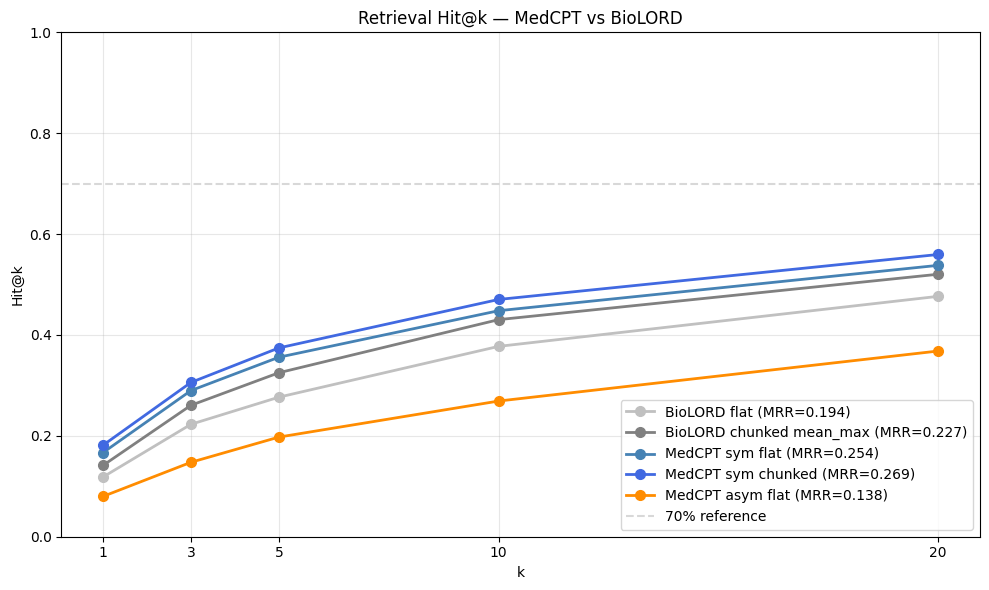

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "BioLORD flat": "silver",
    "BioLORD chunked mean_max": "gray",
    "MedCPT sym flat": "steelblue",
    "MedCPT sym chunked": "royalblue",
    "MedCPT asym flat": "darkorange",
}

for name, res in all_results.items():
    ks_list = list(res["hits"].keys())
    vals = list(res["hits"].values())
    ax.plot(ks_list, vals, "o-", linewidth=2, markersize=7,
            label=f'{name} (MRR={res["mrr"]:.3f})', color=colors.get(name))

ax.set_xlabel("k")
ax.set_ylabel("Hit@k")
ax.set_title("Retrieval Hit@k — MedCPT vs BioLORD")
ax.set_xticks(KS)
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.3, label="70% reference")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Hit@10 breakdown by class frequency (best MedCPT variant)

Best MedCPT variant: MedCPT sym chunked
freq_bin  hit_at_10  n_queries
       1   0.133333         75
     2-3   0.264286        140
     4-5   0.458333        120
    6-10   0.320988        243
   11-20   0.447581        248
     21+   0.675789        475


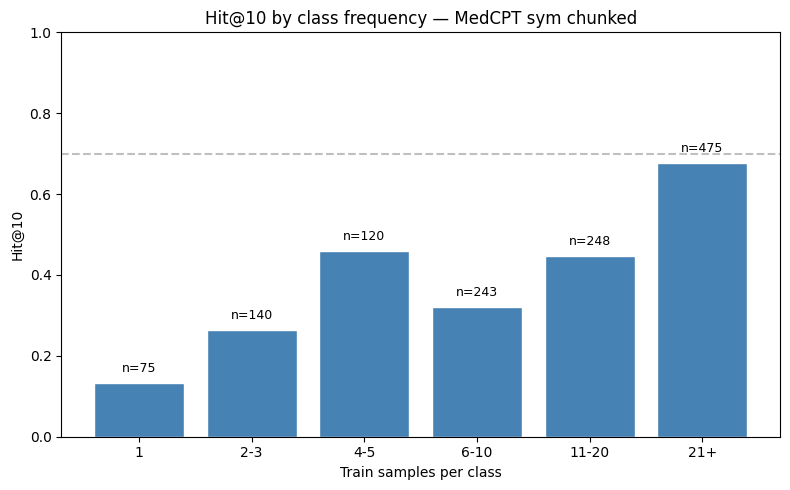

In [16]:
# Pick the best MedCPT variant by Hit@10
best_name = max(
    [k for k in results.keys()],
    key=lambda k: results[k]["hits"][10]
)
best = results[best_name]
print(f"Best MedCPT variant: {best_name}")

y_true = y_test_eval.values
train_counts = y_train.value_counts().to_dict()

results_df = pd.DataFrame({
    "true_label": y_true,
    "train_freq": [train_counts.get(y, 0) for y in y_true],
    "hit_at_10": [y_true[i] in best["retrieved_labels"][i, :10] for i in range(len(y_true))],
})

bins = [0, 1, 3, 5, 10, 20, np.inf]
labels_bin = ["1", "2-3", "4-5", "6-10", "11-20", "21+"]
results_df["freq_bin"] = pd.cut(results_df["train_freq"], bins=bins, labels=labels_bin)

freq_hit = results_df.groupby("freq_bin", observed=False).agg(
    hit_at_10=("hit_at_10", "mean"),
    n_queries=("hit_at_10", "count"),
).reset_index()

print(freq_hit.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(freq_hit["freq_bin"].astype(str), freq_hit["hit_at_10"], color="steelblue", edgecolor="white")
ax.set_xlabel("Train samples per class")
ax.set_ylabel("Hit@10")
ax.set_title(f"Hit@10 by class frequency — {best_name}")
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5)

for i, row in freq_hit.iterrows():
    ax.text(i, row["hit_at_10"] + 0.02, f'n={row["n_queries"]}',
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Cosine similarity distribution: correct vs incorrect (best MedCPT variant)

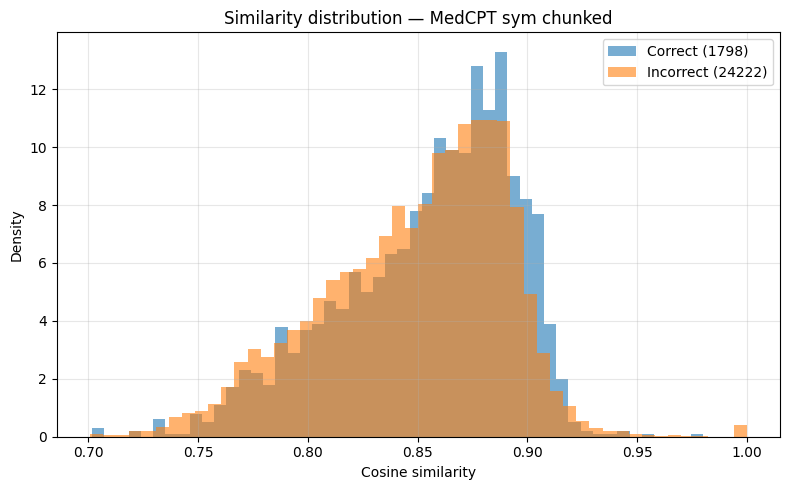

Mean similarity — correct: 0.8546  |  incorrect: 0.8488


In [17]:
similarities = 1 - best["distances"]

correct_sims = []
incorrect_sims = []

for i in range(len(y_true)):
    for j in range(K_MAX):
        if best["retrieved_labels"][i, j] == y_true[i]:
            correct_sims.append(similarities[i, j])
        else:
            incorrect_sims.append(similarities[i, j])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correct_sims, bins=50, alpha=0.6, label=f"Correct ({len(correct_sims)})", density=True)
ax.hist(incorrect_sims, bins=50, alpha=0.6, label=f"Incorrect ({len(incorrect_sims)})", density=True)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title(f"Similarity distribution — {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean similarity — correct: {np.mean(correct_sims):.4f}  |  incorrect: {np.mean(incorrect_sims):.4f}")

### Summary and Analysis

**Setup:** Three MedCPT variants evaluated on the retrieval split (460 evaluable test classes, 1301 test queries, same setup as notebook 04). k-NN cosine retrieval with K=20.

#### Results

| Model | Hit@1 | Hit@5 | Hit@10 | Hit@20 | MRR |
|---|---|---|---|---|---|
| BioLORD flat | 0.1184 | 0.2767 | 0.3774 | 0.4766 | 0.1937 |
| BioLORD chunked mean_max | 0.1414 | 0.3251 | 0.4304 | 0.5204 | 0.2270 |
| MedCPT sym flat | 0.1668 | 0.3559 | 0.4481 | 0.5380 | 0.2536 |
| **MedCPT sym chunked** | **0.1814** | **0.3743** | **0.4704** | **0.5596** | **0.2691** |
| MedCPT asym flat | 0.0799 | 0.1975 | 0.2690 | 0.3682 | 0.1381 |

#### Key findings

**1. MedCPT symmetric outperforms BioLORD across the board.** Best variant (MedCPT sym chunked) improves over BioLORD chunked mean_max by +4.0pp Hit@1, +4.0pp Hit@10, and +4.2pp MRR. A contrastive retrieval model does better than a semantic similarity model for this task, as expected.

**2. Chunking helps MedCPT just as it helped BioLORD.** MedCPT sym chunked beats MedCPT sym flat by +1.5pp Hit@1, +2.2pp Hit@10, +1.6pp MRR. The mean_max aggregation strategy continues to provide consistent gains regardless of the base model.

**3. Asymmetric MedCPT performs worst of all — even below BioLORD flat.** The query encoder's 64-token limit truncates ~90% of clinical descriptions. This confirms that our "queries" are not short search terms but full clinical texts, and forcing them through a short-query encoder destroys critical diagnostic signal.

**4. Similarity gap between correct and incorrect retrievals is very small.** Mean cosine similarity for correct matches (0.8546) vs incorrect (0.8488) shows the embedding space does not clearly separate same-disease cases from different-disease cases. This is the fundamental bottleneck.

**5. Class frequency drives retrieval quality.** Hit@10 ranges from 13% for diseases with 1 training sample to 68% for diseases with 21+ samples. The long-tail distribution of rare diseases is the hardest part of this problem.

#### Conclusions

- **MedCPT sym chunked mean_max is the new best retrieval baseline** (Hit@10 = 0.4704, MRR = 0.2691).
- Switching pretrained models gave a moderate improvement (+4pp), but absolute performance remains below the 60–70% range needed for a useful diagnostic support tool.
- The tiny correct/incorrect similarity gap (0.006) confirms that the bottleneck is not the model architecture but the **lack of disease-level discriminative training**.

#### Next step: contrastive fine-tuning on BioLORD

The most promising direction is **fine-tuning BioLORD-2023** with a contrastive loss (e.g. `MultipleNegativesRankingLoss` or `TripletLoss`) using our dataset, where "same diagnosis = positive pair". Why BioLORD over MedCPT:

- **BioLORD is a symmetric SentenceTransformer**, which matches our task: case-to-case similarity. Fine-tuning is straightforward via the `sentence-transformers` library.
- **MedCPT has two separate encoders** (query/article), designed for asymmetric retrieval. Fine-tuning it for symmetric case-to-case matching would require adapting its architecture, adding unnecessary complexity.
- BioLORD already provides strong biomedical semantic representations — contrastive fine-tuning would specialize it to distinguish between diseases that share similar clinical presentations.

The goal is to reshape the embedding space so that cases of the same disease cluster together and the correct/incorrect similarity gap grows well beyond the current 0.006, making retrieval significantly more reliable.